# 数据分析 part2

以下分析 Vocaloid 歌曲的发布时间特征。

In [22]:
from bs4 import BeautifulSoup
import lxml
import re
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
with open('../data/artist_info.json', 'r', encoding='utf-8') as f:
    artists = json.load(f)
with open('../data/song_info.json', 'r', encoding='utf-8') as f:
    songs = json.load(f)

In [19]:
def extract_pubdate(song_id: str):
    file_path = '../data/page_sources_song/' + song_id + '.html'
    with open(file_path, 'r', encoding='utf-8') as f:
        page_source = f.read()
    soup = BeautifulSoup(page_source, 'lxml')

    tags = soup.find_all('script', string=re.compile('pubDate'))
    info = json.loads(tags[0].text)
    pubdate = info['pubDate']
    return pubdate[:10]

extract_pubdate('409912')

'2008-06-11'

In [ ]:
date_cnt = dict()
for song_id in tqdm(list(songs), desc='统计歌曲发布日期'):
    pubdate = extract_pubdate(song_id)
    year = int(pubdate[:4])
    season = (int(pubdate[5:7]) - 1) // 3 + 1
    key = year * 10 + season
    if key not in date_cnt:
        date_cnt[key] = 1
    else:
        date_cnt[key] += 1

date_sorted = sorted(date_cnt.items())
len(date_cnt), date_sorted

统计歌曲发布日期: 100%|██████████| 2045/2045 [00:25<00:00, 81.01it/s] 


(72,
 [(19701, 204),
  (20001, 1),
  (20073, 69),
  (20074, 4),
  (20082, 5),
  (20083, 4),
  (20091, 9),
  (20092, 9),
  (20093, 20),
  (20094, 8),
  (20101, 17),
  (20102, 12),
  (20103, 31),
  (20104, 20),
  (20111, 18),
  (20112, 10),
  (20113, 23),
  (20114, 17),
  (20121, 30),
  (20122, 39),
  (20123, 38),
  (20124, 20),
  (20131, 43),
  (20132, 48),
  (20133, 35),
  (20134, 39),
  (20141, 46),
  (20142, 18),
  (20143, 30),
  (20144, 17),
  (20151, 29),
  (20152, 18),
  (20153, 30),
  (20154, 16),
  (20161, 24),
  (20162, 23),
  (20163, 15),
  (20164, 19),
  (20171, 12),
  (20172, 3),
  (20173, 37),
  (20174, 20),
  (20181, 13),
  (20182, 9),
  (20183, 19),
  (20184, 6),
  (20191, 4),
  (20192, 9),
  (20193, 6),
  (20194, 21),
  (20201, 15),
  (20202, 11),
  (20203, 14),
  (20204, 12),
  (20211, 15),
  (20212, 26),
  (20213, 35),
  (20214, 24),
  (20221, 36),
  (20222, 36),
  (20223, 44),
  (20224, 58),
  (20231, 60),
  (20232, 53),
  (20233, 73),
  (20234, 63),
  (20241, 65),
  

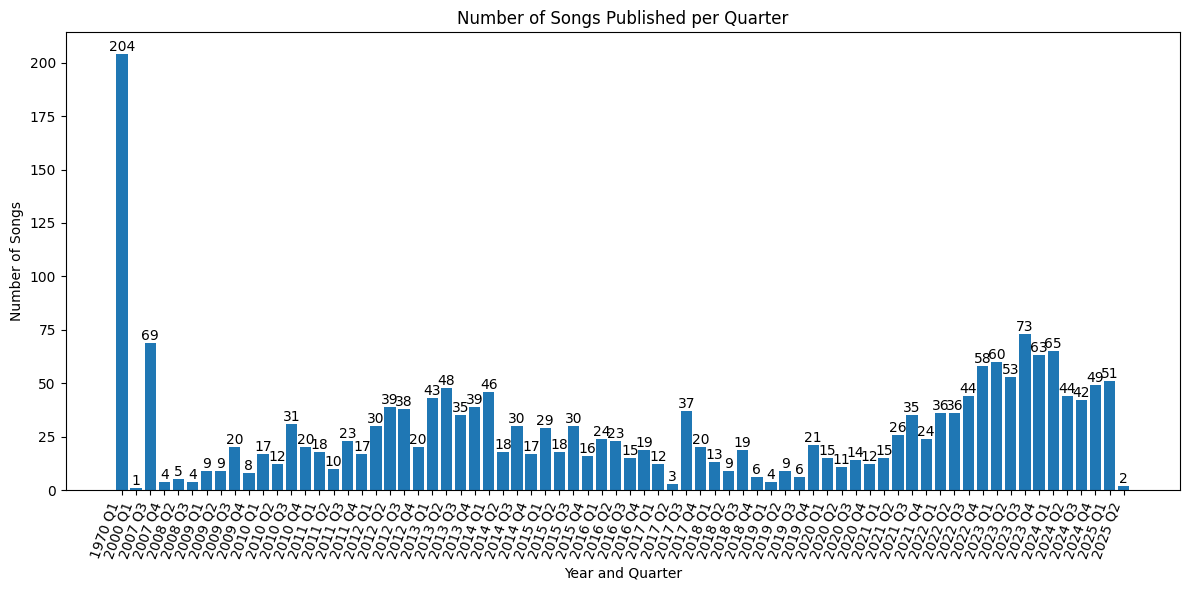

In [32]:
# 准备数据
years_seasons = [f"{item[0]//10} Q{item[0]%10}" for item in date_sorted]
counts = [item[1] for item in date_sorted]

# 创建图形
plt.figure(figsize=(12, 6))

# 绘制柱状图
bars = plt.bar(years_seasons, counts)

# 添加标题和标签
plt.title('Number of Songs Published per Quarter')
plt.xlabel('Year and Quarter')
plt.ylabel('Number of Songs')
plt.xticks(rotation=70, ha='right')  # 旋转x轴标签以便阅读

# 在柱子上方显示数值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

# 调整布局防止标签被截断
plt.tight_layout()

# 显示图形
plt.show()

In [33]:
date_cnt = dict()
for song_id in tqdm(list(songs), desc='统计歌曲发布日期'):
    pubdate = extract_pubdate(song_id)
    year = int(pubdate[:4])
    key = year
    if key not in date_cnt:
        date_cnt[key] = 1
    else:
        date_cnt[key] += 1

date_sorted = sorted(date_cnt.items())
len(date_cnt), date_sorted

统计歌曲发布日期: 100%|██████████| 2045/2045 [00:25<00:00, 80.78it/s] 


(21,
 [(1970, 204),
  (2000, 1),
  (2007, 73),
  (2008, 9),
  (2009, 46),
  (2010, 80),
  (2011, 68),
  (2012, 127),
  (2013, 165),
  (2014, 111),
  (2015, 93),
  (2016, 81),
  (2017, 72),
  (2018, 47),
  (2019, 40),
  (2020, 52),
  (2021, 100),
  (2022, 174),
  (2023, 249),
  (2024, 200),
  (2025, 53)])

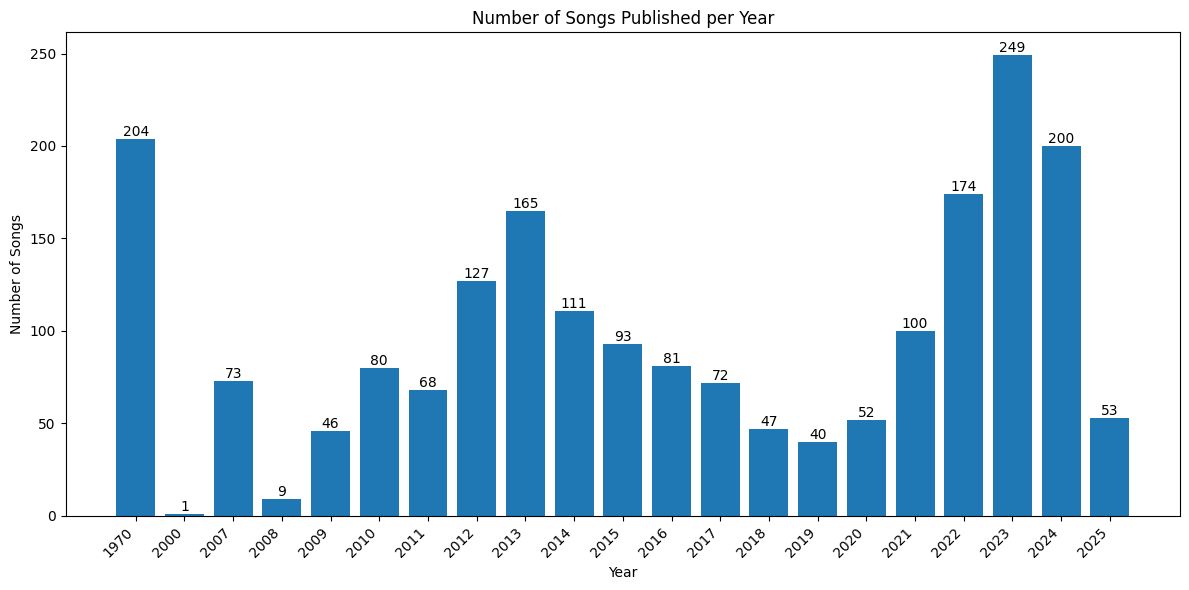

In [35]:
# 准备数据
years = [f"{item[0]}" for item in date_sorted]
counts = [item[1] for item in date_sorted]

# 创建图形
plt.figure(figsize=(12, 6))

# 绘制柱状图
bars = plt.bar(years, counts)

# 添加标题和标签
plt.title('Number of Songs Published per Year')
plt.xlabel('Year')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45, ha='right')  # 旋转x轴标签以便阅读

# 在柱子上方显示数值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

# 调整布局防止标签被截断
plt.tight_layout()

# 显示图形
plt.show()

## 分析

- 被统计在 1970 年的歌曲应该是网易云收录的远古歌曲。

- 2007 年 Vocaloid 歌曲开始大量产生，2013 年左右和 2023 年左右是两个 Vocaloid 歌曲的发布热度高峰。

- 此数据可以印证以下结论：

    - 2007 年虚拟歌姬初音未来的人气飙升推动 Vocaloid 歌曲的迅速发展；
    - 2010 年代 Youtube 、Niconico 动画等平台的快速发展，为 Vocaloid 创作者提供良好的创作者生态和歌曲传播平台；
    - 2022 年后 AI 技术的进步推动了 Vocaloid 音源的变革，新一类 Vocaloid 歌曲开始被大量创作。